In [1]:
import pandas as pd
import numpy as np
import sys
from contextlib import redirect_stdout

from ml_pipeline.subpopulation import run_pipeline, run_model_error_analysis
from ml_evaluation.error_analysis import comprehensive_error_analysis, analyze_feature_contribution_to_errors, create_error_visualization

import warnings
warnings.filterwarnings('ignore')

/home/valeriya/project/homeserve/credit_policy/.direnv/python-3.12.0/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.2) or chardet (7.2.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [2]:
# FILTER TO HIGH PRICE SEGMENT (>75th percentile)
print("\n🎯 FILTERING TO HIGH PRICE SEGMENT (>p75)")
print("="*80)

# Load data
df_quotes = pd.read_csv('cleaned_quote_data.csv')
df_quotes['dt_creation_devis'] = pd.to_datetime(df_quotes['dt_creation_devis'])

# Get average price per customer
avg_price = df_quotes.groupby('numero_compte')['mt_apres_remise_ht_devis'].mean().reset_index()
avg_price.columns = ['customer_id', 'avg_price']

# Get 75th percentile
p75 = avg_price['avg_price'].quantile(0.75)

# Filter high price customers
high_price_ids = avg_price[avg_price['avg_price'] >= p75]['customer_id'].tolist()

# Filter data
df_quotes_high_price = df_quotes[df_quotes['numero_compte'].isin(high_price_ids)].copy()

print(f"Original customers: {df_quotes['numero_compte'].nunique():,}")
print(f"High price customers (>€{p75:.0f}): {len(high_price_ids):,}")
print(f"Quotes: {len(df_quotes_high_price):,}")

# Save to file
df_quotes_high_price.to_csv('cleaned_quote_data_high_price.csv', index=False)
print(f"\n✅ Saved to cleaned_quote_data_high_price.csv")


🎯 FILTERING TO HIGH PRICE SEGMENT (>p75)
Original customers: 25,716
High price customers (>€8829): 6,429
Quotes: 10,094

✅ Saved to cleaned_quote_data_high_price.csv


In [3]:
df_quotes = pd.read_csv('cleaned_quote_data_high_price.csv')


📊 Original quote data: 10,094 quotes from 6,429 customers

🏗️  BUILDING FEATURES FOR SUBPOPULATION CUSTOMERS
Creating OPTIMIZED customer features (mode: first_conversion)...
  Filtering post-first-purchase data...
  Customers: 6,429, Quotes: 9,728
  Calculating features...
  Calculating price trajectory (optimized)...
✓ Created 14 leakage-free features
→ 6,429 customers | 36.5% converters
⏱️  Execution time: 2.8 seconds
✅ SUCCESS! Achieved ≤ 3s target
CREATING SEQUENCE FEATURES (mode: first_conversion)
  Total quotes: 10,094
  Total customers: 6,429
  Using product column: regroup_famille_equipement_produit_principal
  Window days: 30
  Filtering post-first-purchase data...
    Customers after filter: 6,429
    Quotes after filter: 9,754
⚡ Processing 6,429 customers with sequence features...
  Processed 5,000/6,429 customers

  Adding categorical features...

✅ SEQUENCE FEATURES CREATED
  Total customers: 6,429
  Converters: 2,344 (36.5%)
  Features created: 21
  Product column used: 

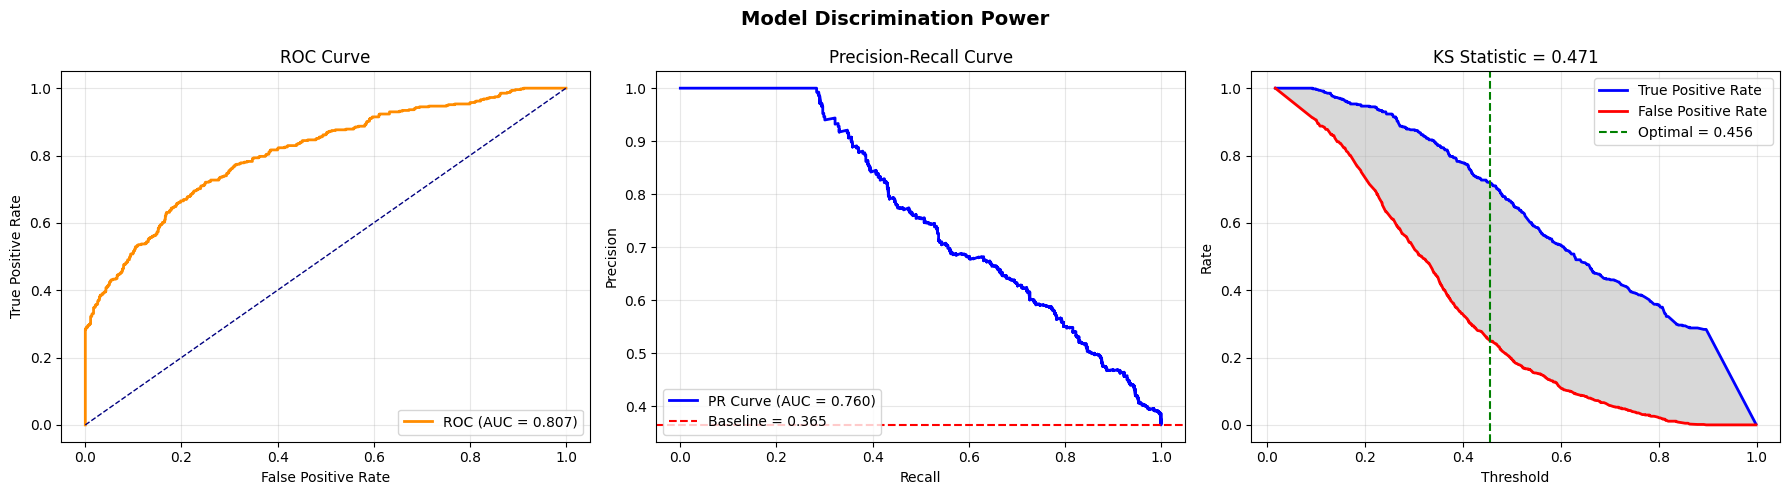

• ROC-AUC: 0.8071
• PR-AUC: 0.7595
• KS Statistic: 0.471 (GOOD discrimination)
• Optimal Threshold: 0.456

💼 STEP 2: BUSINESS IMPACT
----------------------------------------
Verification of decile assignment:
Decile 1 mean prob: 0.997
Decile 10 mean prob: 0.088


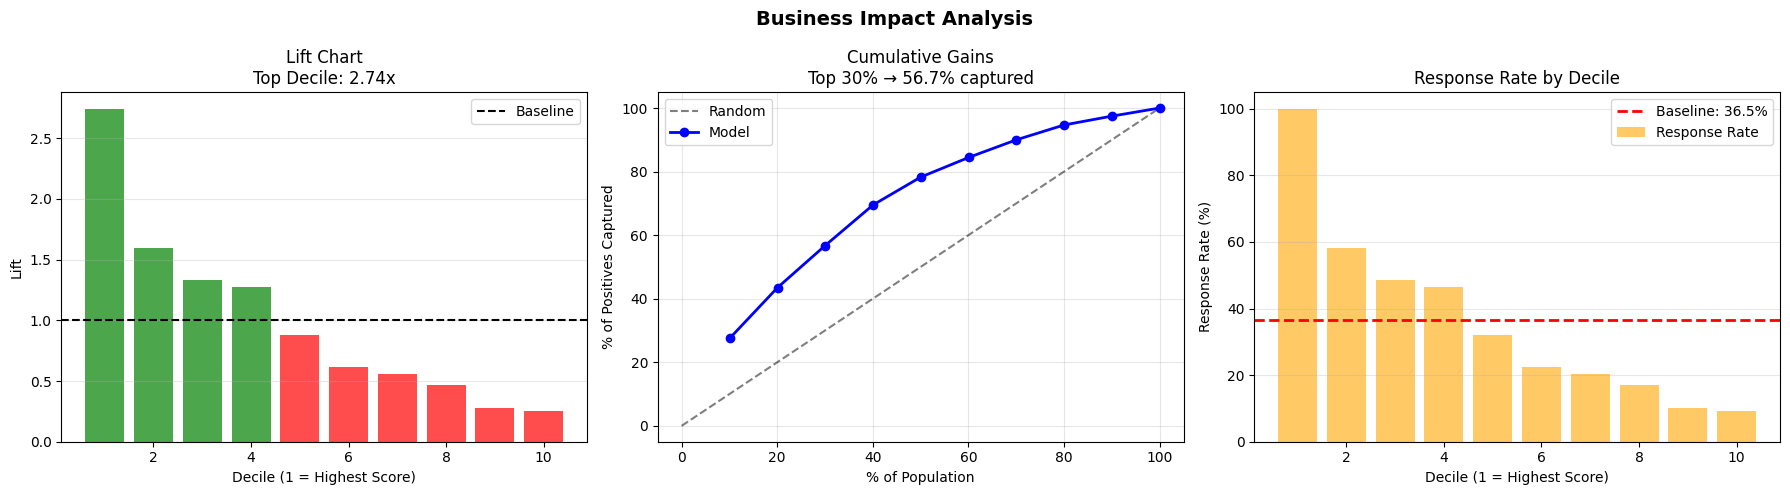

• Top Decile Lift: 0.26x
• Top 30% captures: 56.7% of positives
• Baseline response rate: 36.5%
• Top decile response: 100.0%

📈 STEP 4: CONFUSION MATRIX
----------------------------------------


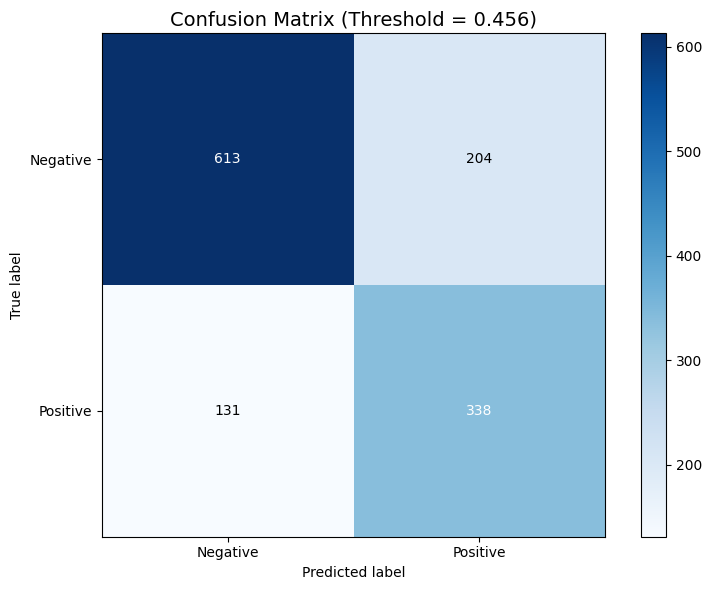

At threshold 0.456:
• Accuracy: 0.740
• Precision: 0.624
• Recall: 0.721
• F1-Score: 0.669
• True Positives: 338
• False Positives: 204
• True Negatives: 613
• False Negatives: 131

FINAL VALIDATION SUMMARY

✅ DISCRIMINATION POWER:
   KS Statistic: 0.471 (GOOD discrimination)

✅ BUSINESS VALUE:
   Efficiency: 0.26x better than random
   Coverage: Top 30% → 56.7% captured

✅ MODEL QUALITY:
   ROC-AUC: 0.8071 (Excellent if >0.8)
   PR-AUC: 0.7595 (Excellent if >0.7)

✅ OPERATIONAL METRICS:
   Optimal Threshold: 0.456
   Precision at threshold: 0.624
   Recall at threshold: 0.721

🔍 FEATURE IMPORTANCE - SUBPOPULATION MODEL

Top 20 Features:
                                     feature  importance
178                  quote_consistency_score    0.088649
251                 max_price_over_min_price    0.036497
250                              value_score    0.031113
102                  max_days_between_quotes    0.022704
205                         decision_quality    0.019269
167         

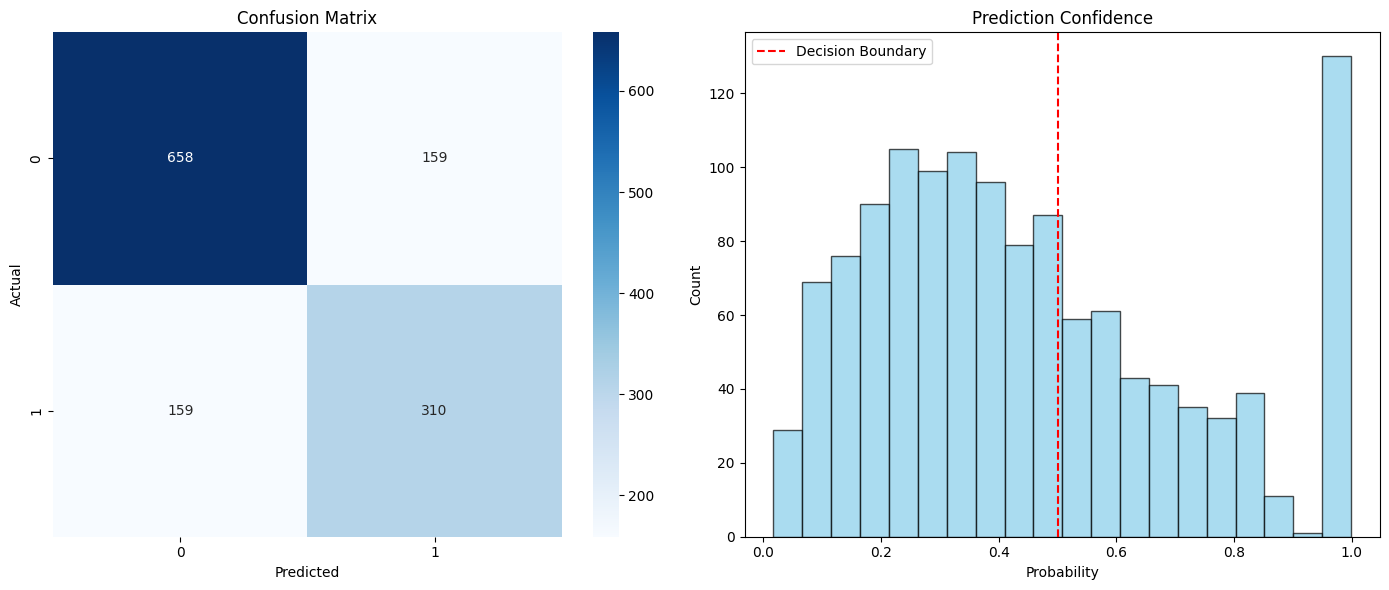

In [4]:
#with redirect_stdout(open('/dev/null', 'w')):
result = run_pipeline(df_quotes)

run_model_error_analysis(result['X_test'], result['y_test'], result['model'])